# **Trabajo Practico N° 3**
**Grupo 3: Nuñez Juliana, Segovia Lucas**

**Importaciones:**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

### **Actividad 1:**

El archivo data_1.txt tiene datos del precio de viviendas en función de la población de la ciudad, o sea:

* **Variable independiente (x)**: Población (en unidades de 10.000 habitantes).  
* **Variable objetivo (y)**: Precio de la vivienda (en unidades de 10.000 dólares). 

**Carga y visualización de datos**: importamos los datos desde el archivo de texto y generamos un gráfico de dispersión para observar la relación inicial entre ambas variables.

Text(0.5, 1.0, 'Población vs Precio de vivienda')

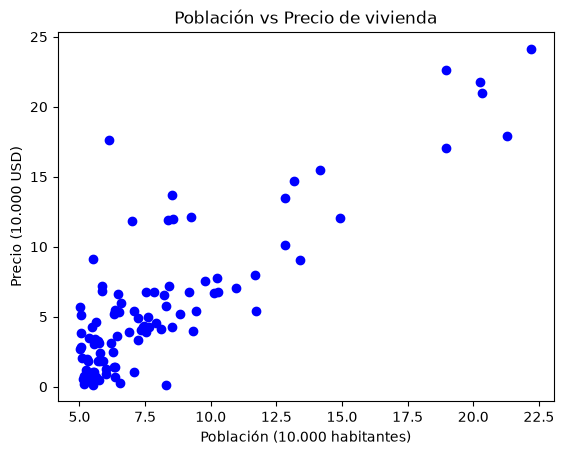

In [4]:
data1 = np.loadtxt('data/data_1.txt', delimiter=',')
# En scikit-learn, la X tiene que ser una matriz de 2 dimensiones, por eso usamos .reshape(-1, 1). La y puede ser un vector simple.
X = data1[:, 0].reshape(-1, 1) 
y = data1[:, 1]

# Diagrama de dispersión
plt.scatter(X, y, color='blue', label='Datos reales')
plt.xlabel('Población (10.000 habitantes)')
plt.ylabel('Precio (10.000 USD)')
plt.title('Población vs Precio de vivienda')

**Ajuste del modelo:** instanciamos y entrenamos nuestro modelo de regresión lineal simple, usando el conjunto de datos cargado en la actividad anterior.

In [5]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.17]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.581
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[37.92]


**Extracción de parámetros:** Una vez entrenado el modelo le pedimos a la librería que nos devuelva los parámetros matemáticos exactos que encontró (el término independiente y la pendiente) y los de los parametros usados.

In [9]:
w0 = modelo_lineal.intercept_
w1 = modelo_lineal.coef_[0]
print(f"El término independiente (w0) es: {w0:.4f}")
print(f"La pendiente (w1) es: {w1:.4f}")

# Configuración del modelo
parametros_config = modelo_lineal.get_params()
print(f"Parámetros de configuración: {parametros_config}")

# Interpretación teórica (Vector W)
print(f"Vector de parámetros W: [{w0:.4f}, {w1:.4f}]")

El término independiente (w0) es: -3.5810
La pendiente (w1) es: 1.1698
Parámetros de configuración: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Vector de parámetros W: [-3.5810, 1.1698]


**Gráfico de la recta ajustada:** Para comprobar el resultado de manera visual superponemos la recta de predicción calculada por el modelo sobre los puntos originales.

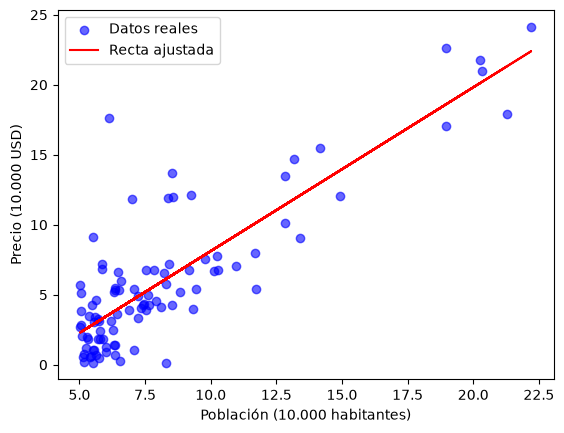

In [10]:
plt.scatter(X, y, color='blue', alpha=0.6, label='Datos reales')

y_predicha = modelo_lineal.predict(X)
plt.plot(X, y_predicha, color='red', label='Recta ajustada')

plt.xlabel('Población (10.000 habitantes)')
plt.ylabel('Precio (10.000 USD)')
plt.legend()
plt.show()

**Interpretación de la pendiente:** analizamos qué representa numéricamente el valor de la pendiente obtenida dentro del contexto real del problema (poblaciones y precios).

La pendiente obtenida en nuestro modelo es $w_1 = 1.1698$.

- **Interpretación del signo:** El signo positivo indica que existe una relación lineal directa (positiva) entre la población de la ciudad y el precio de las viviendas, a medida que aumente la población, el precio de las viviendas también aumenta.
- **Interpretación de la magnitud:** teniendo en cuanta que la variable de entrada (x) está en unidades de 10.000 habitantes (1x = 10.000 habitantes) y la variable objetivo (y) en unidades de 10.000 dólares (1y = 10.000 dólares), por cada unidad que x aumente, y va a aumentar una magnitud de 1.1698 unidades, por lo que el precio de la vivienda aumenta en promedio 11.698 dólares por cada 10.000 habitantes (calculado como $1.1698 \times 10.000$).